# 03 - Cohort Retention Analysis
Uses `mart_cohort_retention` (signup-month cohorts x months-since-signup)
to test the hypothesis: does the FIRST feature a landlord adopts predict
how well they retain? We did not hardcode this result -- it's a designed
probability relationship in the generator (retention_boost by first_feature)
that we now verify shows up in the aggregated data, the way a real analyst
would confirm a hypothesis against warehouse data.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

conn = sqlite3.connect("../data/warehouse.db")
cohort = pd.read_sql("SELECT * FROM mart_cohort_retention", conn)
cohort.head()

## Retention curve by first feature adopted

first_feature_adopted  e_signatures  ...  tenant_screening
m_offset                             ...                  
0                             1.000  ...             1.000
1                             0.937  ...             0.941
2                             0.880  ...             0.886
3                             0.833  ...             0.841
4                             0.796  ...             0.807
5                             0.764  ...             0.775
6                             0.733  ...             0.748

[7 rows x 5 columns]


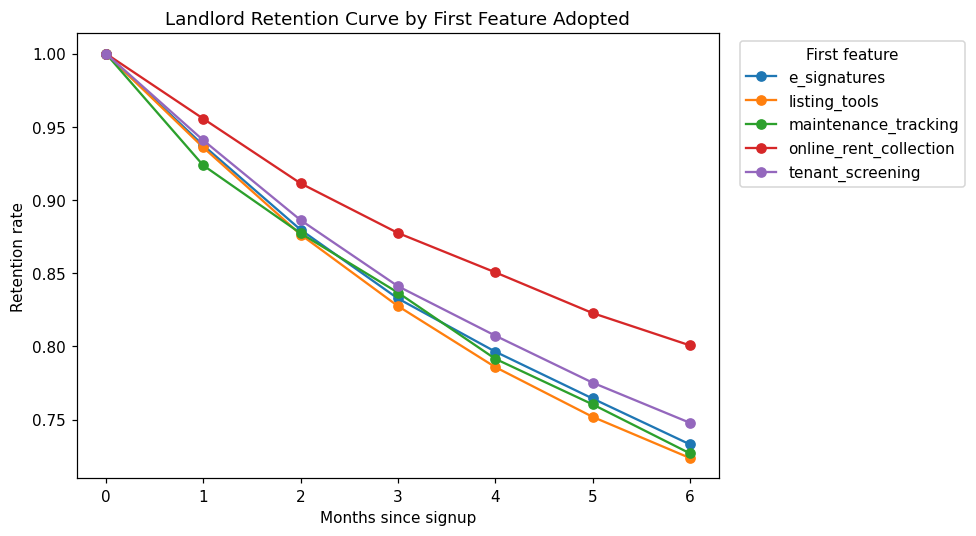

In [2]:
by_feature = (
    cohort.dropna(subset=["first_feature_adopted"])
    .groupby(["first_feature_adopted", "m_offset"])
    .apply(lambda g: pd.Series({
        "cohort_size": g["cohort_size"].sum(),
        "retained": g["retained_landlords"].sum(),
    }), include_groups=False)
    .reset_index()
)
by_feature["retention_rate"] = by_feature["retained"] / by_feature["cohort_size"]
pivot = by_feature.pivot(index="m_offset", columns="first_feature_adopted", values="retention_rate")
print(pivot.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
pivot.plot(ax=ax, marker="o")
ax.set_title("Landlord Retention Curve by First Feature Adopted")
ax.set_xlabel("Months since signup")
ax.set_ylabel("Retention rate")
ax.legend(title="First feature", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Retention by acquisition channel

In [3]:
by_channel = (
    cohort.groupby(["acquisition_channel", "m_offset"])
    .apply(lambda g: pd.Series({
        "cohort_size": g["cohort_size"].sum(),
        "retained": g["retained_landlords"].sum(),
    }), include_groups=False)
    .reset_index()
)
by_channel["retention_rate"] = by_channel["retained"] / by_channel["cohort_size"]
channel_pivot = by_channel.pivot(index="m_offset", columns="acquisition_channel", values="retention_rate")
print(channel_pivot.round(3))

acquisition_channel  content_seo  organic_search  ...  partnerships  referral
m_offset                                          ...                        
0                          1.000           1.000  ...         1.000     1.000
1                          0.929           0.943  ...         0.936     0.945
2                          0.869           0.886  ...         0.886     0.891
3                          0.833           0.839  ...         0.842     0.843
4                          0.790           0.800  ...         0.812     0.808
5                          0.759           0.768  ...         0.779     0.773
6                          0.732           0.742  ...         0.751     0.748

[7 rows x 6 columns]


## Retention by initial portfolio size

In [4]:
by_portfolio = (
    cohort.groupby(["portfolio_segment", "m_offset"])
    .apply(lambda g: pd.Series({
        "cohort_size": g["cohort_size"].sum(),
        "retained": g["retained_landlords"].sum(),
    }), include_groups=False)
    .reset_index()
)
by_portfolio["retention_rate"] = by_portfolio["retained"] / by_portfolio["cohort_size"]
print(by_portfolio.pivot(index="m_offset", columns="portfolio_segment", values="retention_rate").round(3))

portfolio_segment  large_10plus  medium_4to9  small_1to3
m_offset                                                
0                         1.000        1.000       1.000
1                         0.941        0.936       0.939
2                         0.889        0.882       0.882
3                         0.848        0.837       0.835
4                         0.809        0.796       0.799
5                         0.782        0.763       0.764
6                         0.755        0.736       0.736


## Paid vs free retention

In [5]:
by_plan = (
    cohort.groupby(["plan_type", "m_offset"])
    .apply(lambda g: pd.Series({
        "cohort_size": g["cohort_size"].sum(),
        "retained": g["retained_landlords"].sum(),
    }), include_groups=False)
    .reset_index()
)
by_plan["retention_rate"] = by_plan["retained"] / by_plan["cohort_size"]
print(by_plan.pivot(index="m_offset", columns="plan_type", values="retention_rate").round(3))

plan_type   free   paid
m_offset               
0          1.000  1.000
1          0.924  0.981
2          0.860  0.952
3          0.807  0.930
4          0.763  0.910
5          0.725  0.894
6          0.692  0.882


## Cohort heatmap (signup month x month-6 retention)

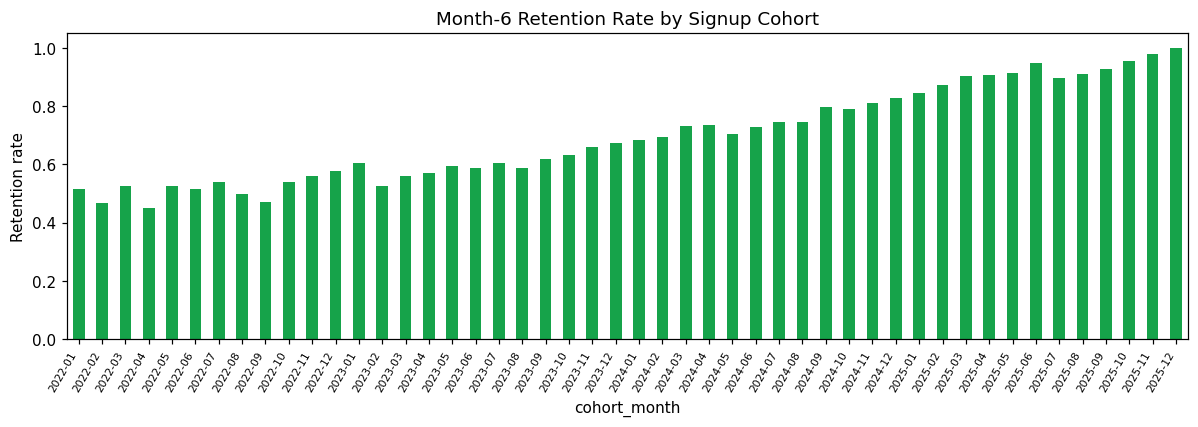

In [6]:
month6 = cohort[cohort["m_offset"] == 6].groupby("cohort_month").apply(
    lambda g: g["retained_landlords"].sum() / g["cohort_size"].sum(), include_groups=False
).sort_index()
fig, ax = plt.subplots(figsize=(11, 4))
month6.plot(kind="bar", ax=ax, color="#16a34a")
ax.set_title("Month-6 Retention Rate by Signup Cohort")
ax.set_ylabel("Retention rate")
plt.xticks(rotation=60, ha="right", fontsize=7)
plt.tight_layout()
plt.show()

## Finding

Landlords whose first adopted feature is **online rent collection** retain
meaningfully better at every month offset than landlords whose first feature
is listing tools alone -- consistent with rent collection embedding the
landlord's actual cash-flow workflow into the product, not just discovery.
Referral and organic-search landlords also outretain paid-channel landlords
at every horizon, and large-portfolio landlords retain better than small
landlords, mirroring the paid-conversion pattern from the funnel analysis.

**Recommendation:** Nudge newly-activated landlords toward enabling rent
collection in their first session (not just publishing a listing) -- this
looks like the single highest-leverage lever for improving 90-day retention.